## Carleton School of Information Technology
### ITEC 5920 – Applied Deep Learning
### Winter 2025
### Instructor: Dr. Marzieh Amini
### Prepared by: Aziz Al-Najjar

sources:
- <a href="https://machinelearningmastery.com/an-introduction-to-recurrent-neural-networks-and-the-math-that-powers-them">An Introduction to Recurrent Neural Networks and the Math That Powers Them</a> 
- <a href="https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn">Recurrent Neural Network(RNN) Tutorial: Types, Examples, LSTM and More</a> 
- <a href="https://www.tensorflow.org/guide/keras/rnn">Recurrent Neural Networks (RNN) with Keras</a>
- <a href="https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/">Understanding Simple Recurrent Neural Networks in Keras</a>
- <a href="https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/">How to Develop LSTM Models for Time Series Forecasting</a> 
- <a href="https://towardsdatascience.com/implementation-of-rnn-lstm-and-gru-a4250bf6c090#:~:text=GRU%20implementation%20in%20Keras.&text=The%20GRU%20comprises%20of%20the,previous%20memory%20to%20keep%20around.">Implementation of RNN, LSTM, and GRU</a> 

This tutorial is designed for anyone looking for an understanding of how recurrent neural networks (RNN) work and how to use them via the Keras deep learning library. 
While the Keras library provides all the methods required for solving problems and building applications, it is also important to gain an insight into how everything works. In this tutorial, the computations taking place in the RNN model are shown step by step. Next, a complete end-to-end system for time series prediction is developed.

After completing this tutorial, you will know:

- The structure of an RNN
- How an RNN computes the output when given an input
- How to prepare data for a SimpleRNN in Keras
- How to train a SimpleRNN model

This tutorial is divided into two parts; they are:

1. The structure of the RNN
    1. Different weights and biases associated with different layers of the RNN
    2. How computations are performed to compute the output when given an input
2. A complete application for time series prediction

It is assumed that you have a basic understanding of RNNs before you start implementing them.  <a href="https://machinelearningmastery.com/an-introduction-to-recurrent-neural-networks-and-the-math-that-powers-them">An Introduction to Recurrent Neural Networks and the Math That Powers Them</a> or <a href="https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn">Recurrent Neural Network(RNN) Tutorial: Types, Examples, LSTM and More</a> gives you a quick overview of RNNs. 


# Import Section
To start the implementation of RNNs, let’s add the import section.

In [65]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM, GRU
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt
from keras.backend import clear_session

# SimpleRNN

The function below returns a model that includes a SimpleRNN layer and a Dense layer for learning sequential data. The input_shape specifies the parameter (time_steps x features). We’ll simplify everything and use univariate data, i.e., one feature only; the time steps are discussed below.

In [30]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, 
                        activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
 
demo_model = create_RNN(2, 1, (3,1), activation=['linear', 'linear'])

The object demo_model is returned with two hidden units created via the SimpleRNN layer and one dense unit created via the Dense layer. The input_shape is set at 3×1, and a linear activation function is used in both layers for simplicity. Just to recall, the linear activation function 
__f(x) = x__ makes no change in the input. The network looks as follows:

If we have *m* hidden units (m = 2 in the above case), then:

- Input:  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>$x$</mi>
  <mo>&#x2208;</mo>
  <mi>$R$</mi>
</math>
- Hidden unit: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <mi>$h$</mi>
  <mo>&#x2208;</mo>
  <msup>
    <mi>$R^m$</mi>
  </msup>
</math>
- Weights for the input units: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>$w_x$</mi>
    <mi> </mi>
  </msub>
  <mo>&#x2208;</mo>
  <msup>
    <mi>$R^m$</mi>
  </msup>
</math>
- Weights for the hidden units: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>$w_h$</mi>
  </msub>
  <mo>&#x2208;</mo>
  <msup>
    <mi>$R^{m x m}$</mi>
    <mrow data-mjx-texclass="ORD">
      <mi> </mi>
    </mrow>
  </msup>
</math>
- Bias for the hidden units: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>$b_h$</mi>
  </msub>
  <mo>&#x2208;</mo>
  <msup>
    <mi>$R^m$</mi>
  </msup>
</math>
- Weight for the dense layer: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>$w_y$</mi>
  </msub>
  <mo>&#x2208;</mo>
  <msup>
    <mi>$R^m$</mi>
  </msup>
</math>
- Bias for the dense layer: <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>$b_y$</mi>
  </msub>
  <mo>&#x2208;</mo>
  <mi>$R$</mi>
</math>

Let’s look at the above weights. Note: As the weights are randomly initialized, the results posted here will be different from yours. The important thing is to learn what the structure of each object being used looks like and how it interacts with others to produce the final output.

In [31]:
wx = demo_model.get_weights()[0]
wh = demo_model.get_weights()[1]
bh = demo_model.get_weights()[2]
wy = demo_model.get_weights()[3]
by = demo_model.get_weights()[4]

print(' wx = ', wx, '\n wh = ', wh, '\n bh = ', bh, '\n wy =', wy, '\n by = ', by)

 wx =  [[-0.04870319 -0.37177265]] 
 wh =  [[ 0.78166986 -0.6236923 ]
 [-0.6236923  -0.78167   ]] 
 bh =  [0. 0.] 
 wy = [[1.191485  ]
 [0.08823323]] 
 by =  [0.]


Now let’s do a simple experiment to see how the layers from a SimpleRNN and Dense layer produce an output. Keep this figure in view.

![RNN Code](https://machinelearningmastery.com/wp-content/uploads/2021/09/rnnCode1.png)


We’ll input x for three time steps and let the network generate an output. The values of the hidden units at time steps 1, 2, and 3 will be computed. $h_0$ is initialized to the zero vector. The output $o_3$ is computed from $h_3$ and $w_y$. An activation function is not required as we are using linear units.

In [32]:
x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features 
x_input = np.reshape(x,(1, 3, 1))
y_pred_model = demo_model.predict(x_input)


m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + h0 + bh
h2 = np.dot(x[1], wx) + np.dot(h1,wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2,wh) + bh
o3 = np.dot(h3, wy) + by

print('h1 = ', h1,'h2 = ', h2,'h3 = ', h3)

print("Prediction from network ", y_pred_model)
print("Prediction from our computation ", o3)

1/1 [==============================] - 0s 193ms/step
h1 =  [[-0.04870319 -0.37177265]] h2 =  [[ 0.09639552 -0.42256597]] h3 =  [[ 0.19279103 -0.84513195]]
Prediction from network  [[0.15513888]]
Prediction from our computation  [[0.1551389]]


### Running the RNN on Sunspots Dataset

Now that we understand how the SimpleRNN and Dense layers are put together. Let’s run a complete RNN on a simple time series dataset. We’ll need to follow these steps:

1. Read the dataset from a given URL
2. Split the data into training and test sets
3. Prepare the input to the required Keras format
4. Create an RNN model and train it
5. Make the predictions on training and test sets and print the root mean square error on both sets
6. View the result

#### Step 1, 2: Reading Data and Splitting Into Train and Test
The following function reads the train and test data from a given URL and splits it into a given percentage of train and test data. It returns single-dimensional arrays for train and test data after scaling the data between 0 and 1 using MinMaxScaler from scikit-learn

In [33]:
def get_train_test(url, split_percent=0.8):
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()
    n = len(data)
    # Point for splitting data into train and test
    split = int(n*split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data
 
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

#### Step 3: Reshaping Data for Keras
The next step is to prepare the data for Keras model training. The input array should be shaped as: total_samples x time_steps x features.

There are many ways of preparing time series data for training. We’ll create input rows with non-overlapping time steps. An example for time steps = 2 is shown in the figure below. Here, time steps denotes the number of previous time steps to use for predicting the next value of the time series data.

![RNN Code](https://machinelearningmastery.com/wp-content/uploads/2021/09/rnnCode2.png)


The following function get_XY() takes a one-dimensional array as input and converts it to the required input X and target Y arrays. We’ll use 12 time_steps for the sunspots dataset as the sunspots generally have a cycle of 12 months. You can experiment with other values of time_steps.

In [34]:
# Prepare the input X and target Y
def get_XY(dat, time_steps):
    # Indices of target array
    Y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[Y_ind]
    # Prepare X
    rows_x = len(Y)
    X = dat[range(time_steps*rows_x)]
    X = np.reshape(X, (rows_x, time_steps, 1))    
    return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

#### Step 4: Create RNN Model and Train
For this step, you can reuse your create_RNN() function that was defined above.

In [35]:
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), 
                   activation=['tanh', 'tanh'])
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20
187/187 - 2s - loss: 0.0185 - 2s/epoch - 8ms/step
Epoch 2/20
187/187 - 1s - loss: 0.0090 - 529ms/epoch - 3ms/step
Epoch 3/20
187/187 - 1s - loss: 0.0078 - 525ms/epoch - 3ms/step
Epoch 4/20
187/187 - 0s - loss: 0.0070 - 480ms/epoch - 3ms/step
Epoch 5/20
187/187 - 0s - loss: 0.0064 - 476ms/epoch - 3ms/step
Epoch 6/20
187/187 - 1s - loss: 0.0060 - 506ms/epoch - 3ms/step
Epoch 7/20
187/187 - 0s - loss: 0.0057 - 496ms/epoch - 3ms/step
Epoch 8/20
187/187 - 1s - loss: 0.0056 - 520ms/epoch - 3ms/step
Epoch 9/20
187/187 - 1s - loss: 0.0053 - 671ms/epoch - 4ms/step
Epoch 10/20
187/187 - 1s - loss: 0.0049 - 970ms/epoch - 5ms/step
Epoch 11/20
187/187 - 1s - loss: 0.0048 - 1s/epoch - 6ms/step
Epoch 12/20
187/187 - 1s - loss: 0.0047 - 1s/epoch - 6ms/step
Epoch 13/20
187/187 - 1s - loss: 0.0046 - 1s/epoch - 6ms/step
Epoch 14/20
187/187 - 1s - loss: 0.0045 - 1s/epoch - 6ms/step
Epoch 15/20
187/187 - 1s - loss: 0.0043 - 799ms/epoch - 4ms/step
Epoch 16/20
187/187 - 1s - loss: 0.0043 - 517ms/e

#### Step 5: Compute and Print the Root Mean Square Error

The function print_error() computes the mean square error between the actual and predicted values.

In [37]:
def print_error(trainY, testY, train_predict, test_predict):    
    # Error of predictions
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
    # Print RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))    

# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)
# Mean square error
print_error(trainY, testY, train_predict, test_predict)

2/2 [==============================] - 0s 6ms/step
Train RMSE: 0.064 RMSE
Test RMSE: 0.100 RMSE


#### Step 6: View the Result
The following function plots the actual target values and the predicted values. The red line separates the training and test data points.

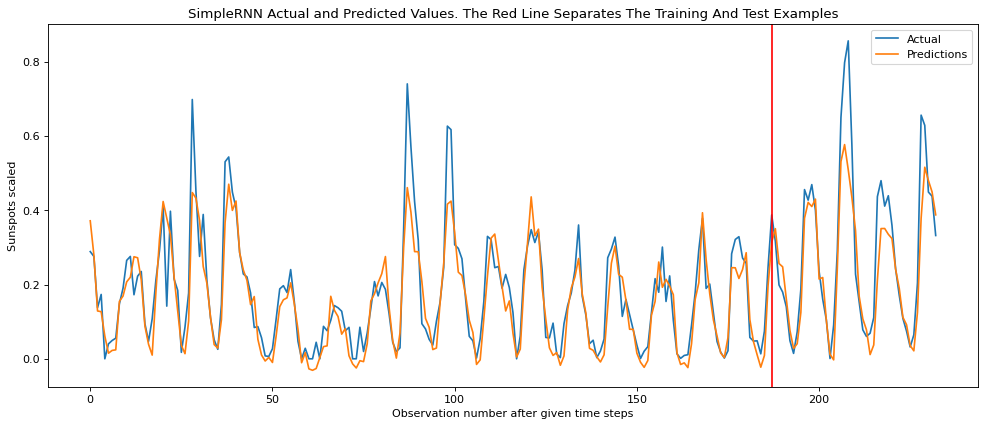

In [38]:
# Plot the result
def plot_result(trainY, testY, train_predict, test_predict, model_name):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Sunspots scaled')
    plt.title(model_name + ' Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plot_result(trainY, testY, train_predict, test_predict, "SimpleRNN")

# LSTM: Long Short-Term Memory networks

LSTM, also known as the Long Short Term Memory is an RNN architecture with feedback connections, which enables it to perform or compute anything that a Turing machine can.

A single LSTM unit is composed of a cell, an input gate, an output gate and a forget gate, which facilitates the cell to remember values for an arbitrary amount of time. The gates control the flow of information in and out the LSTM cell.

The hidden state hₜ for an LSTM cell can be calculated as follows:

![RNN Code](https://miro.medium.com/v2/resize:fit:640/format:webp/1*PcX0vEEvir-zHdq5x4EPiw.png)

Here, i, f, o are called the input, forget and output gates, respectively. Note that they have the exact same equations, just with different parameter matrices (W is the recurrent connection at the previous hidden layer and current hidden layer, U is the weight matrix connecting the inputs to the current hidden layer).

We are going to use the same dataset for the SimpleRNN as well as print_error() and plot_result() functions created in the previous section

Lets first create a function that returns an LSTM model

In [50]:
def create_LSTM(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential()
    model.add(LSTM(hidden_units, input_shape=input_shape, 
                        activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
 


Now we will train the model using the trainX and trainY from Steps 1,2,3 in the previous section

In [59]:
LSTM_model = create_LSTM(hidden_units=3, dense_units=1, input_shape=(time_steps,1), 
                   activation=['tanh', 'tanh'])
LSTM_model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20
187/187 - 3s - loss: 0.0343 - 3s/epoch - 13ms/step
Epoch 2/20
187/187 - 1s - loss: 0.0150 - 688ms/epoch - 4ms/step
Epoch 3/20
187/187 - 1s - loss: 0.0074 - 715ms/epoch - 4ms/step
Epoch 4/20
187/187 - 1s - loss: 0.0054 - 649ms/epoch - 3ms/step
Epoch 5/20
187/187 - 1s - loss: 0.0053 - 646ms/epoch - 3ms/step
Epoch 6/20
187/187 - 1s - loss: 0.0053 - 699ms/epoch - 4ms/step
Epoch 7/20
187/187 - 1s - loss: 0.0053 - 672ms/epoch - 4ms/step
Epoch 8/20
187/187 - 1s - loss: 0.0049 - 939ms/epoch - 5ms/step
Epoch 9/20
187/187 - 1s - loss: 0.0049 - 1s/epoch - 6ms/step
Epoch 10/20
187/187 - 1s - loss: 0.0047 - 975ms/epoch - 5ms/step
Epoch 11/20
187/187 - 1s - loss: 0.0046 - 697ms/epoch - 4ms/step
Epoch 12/20
187/187 - 1s - loss: 0.0046 - 664ms/epoch - 4ms/step
Epoch 13/20
187/187 - 1s - loss: 0.0044 - 689ms/epoch - 4ms/step
Epoch 14/20
187/187 - 1s - loss: 0.0044 - 725ms/epoch - 4ms/step
Epoch 15/20
187/187 - 1s - loss: 0.0045 - 651ms/epoch - 3ms/step
Epoch 16/20
187/187 - 1s - loss: 0.0043

Lets computes the mean square error between the actual and predicted values for the LSTM model

In [61]:
# make predictions
LSTM_train_predict = LSTM_model.predict(trainX)
LSTM_test_predict = LSTM_model.predict(testX)
# Mean square error
print_error(trainY, testY, LSTM_train_predict, LSTM_test_predict)


2/2 [==============================] - 0s 7ms/step
Train RMSE: 0.063 RMSE
Test RMSE: 0.092 RMSE


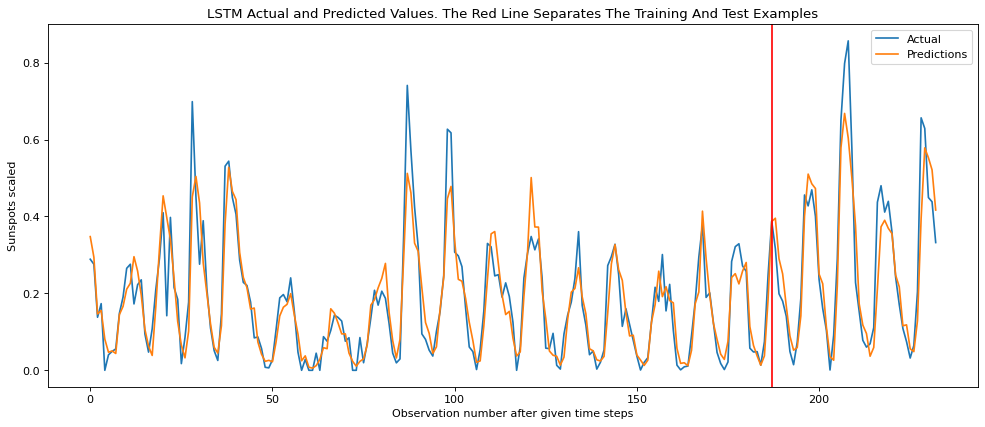

In [45]:
plot_result(trainY, testY, LSTM_train_predict, LSTM_test_predict, "LSTM")

There are more complicated and differnet types of the LSTM models depending on the data and application. I recommend you to go over <a href="https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/">How to Develop LSTM Models for Time Series Forecasting</a>  To learn more about different LSTM models using keras

## GRU 

The GRU, known as the Gated Recurrent Unit is an RNN architecture, which is similar to LSTM units. The GRU comprises of the reset gate and the update gate instead of the input, output and forget gate of the LSTM.

The reset gate determines how to combine the new input with the previous memory, and the update gate defines how much of the previous memory to keep around. If we set the reset to all 1’s and update gate to all 0’s we again arrive at our plain RNN model.

For the GRU the hidden state hₜ can be calculated as follows:

![RNN Code](https://miro.medium.com/v2/resize:fit:640/format:webp/1*VCgvWe30mFdSvK93p7zUJg.png)

Here r is a reset gate, and z is an update gate.

Lets first create a function that returns an GRU model

In [66]:
def create_GRU(hidden_units, dense_units, input_shape, activation):
    clear_session()
    model = Sequential()
    model.add(GRU(hidden_units, input_shape=input_shape, 
                        activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model
 

Now we will train the model using the trainX and trainY from Steps 1,2,3 in the RNN section

In [67]:
GRU_model = create_GRU(hidden_units=3, dense_units=1, input_shape=(time_steps,1), 
                   activation=['tanh', 'tanh'])
GRU_model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20
187/187 - 3s - loss: 0.0679 - 3s/epoch - 18ms/step
Epoch 2/20
187/187 - 1s - loss: 0.0372 - 637ms/epoch - 3ms/step
Epoch 3/20
187/187 - 1s - loss: 0.0282 - 679ms/epoch - 4ms/step
Epoch 4/20
187/187 - 1s - loss: 0.0213 - 667ms/epoch - 4ms/step
Epoch 5/20
187/187 - 1s - loss: 0.0157 - 727ms/epoch - 4ms/step
Epoch 6/20
187/187 - 1s - loss: 0.0111 - 1s/epoch - 5ms/step
Epoch 7/20
187/187 - 1s - loss: 0.0074 - 1s/epoch - 6ms/step
Epoch 8/20
187/187 - 1s - loss: 0.0056 - 818ms/epoch - 4ms/step
Epoch 9/20
187/187 - 1s - loss: 0.0047 - 685ms/epoch - 4ms/step
Epoch 10/20
187/187 - 1s - loss: 0.0045 - 645ms/epoch - 3ms/step
Epoch 11/20
187/187 - 1s - loss: 0.0043 - 659ms/epoch - 4ms/step
Epoch 12/20
187/187 - 1s - loss: 0.0043 - 642ms/epoch - 3ms/step
Epoch 13/20
187/187 - 1s - loss: 0.0042 - 682ms/epoch - 4ms/step
Epoch 14/20
187/187 - 1s - loss: 0.0041 - 637ms/epoch - 3ms/step
Epoch 15/20
187/187 - 1s - loss: 0.0041 - 671ms/epoch - 4ms/step
Epoch 16/20
187/187 - 1s - loss: 0.0042 - 

Lets computes the mean square error between the actual and predicted values for the LSTM model

In [68]:
# make predictions
GRU_train_predict = GRU_model.predict(trainX)
GRU_test_predict = GRU_model.predict(testX)
# Mean square error
print_error(trainY, testY, GRU_train_predict, GRU_test_predict)


2/2 [==============================] - 0s 7ms/step
Train RMSE: 0.061 RMSE
Test RMSE: 0.089 RMSE


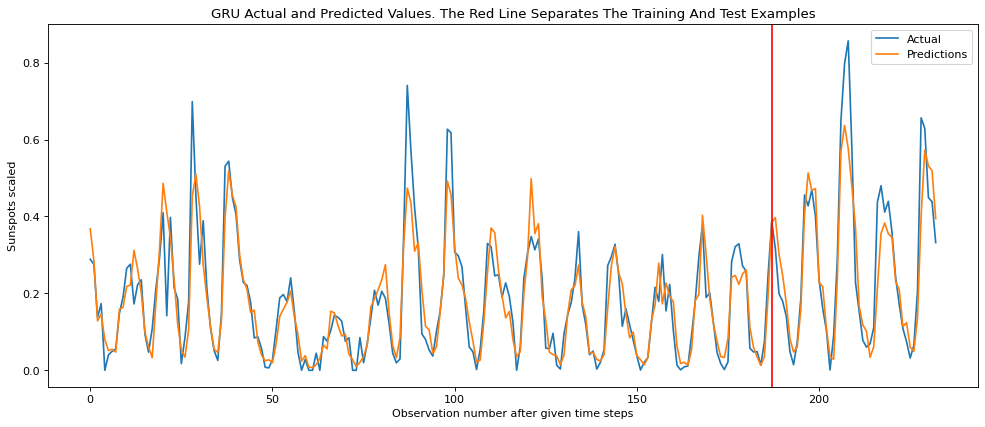

In [71]:
plot_result(trainY, testY, GRU_train_predict, GRU_test_predict, "GRU")

### Summary

In this tutorial, you discovered recurrent neural networks and their various architectures.

Specifically, you learned:

- The structure of RNNs
- How the RNN computes an output from previous inputs
- How to implement an end-to-end system for time series forecasting using, RNN, LSTM, and GRU